# Section 0. Setup

In [2]:
import os
import gc
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils import class_weight
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm
import whisper
from transformers import pipeline
import torch
from collections import defaultdict
from datetime import datetime

# Reproducibility for Reviewer Validation
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

class Config:
    # Data Settings
    DATA_PATH = 'dataset_meld/'
    FILE_PREFIX = 'prepared_'
    SR = 16000
    MAX_DURATION = 3
    MAX_SAMPLES = SR * MAX_DURATION
    
    # Feature Settings
    N_MFCC = 40
    MAX_MFCC_LEN = 94  
    
    # Training Parameters 
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 30
    DROPOUT = 0.3
    
    DEFAULT_CLASSES = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']

print("=== Hyperparameters ===")
for k, v in vars(Config).items():
    if not k.startswith('__'): print(f"{k}: {v}")

c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Hyperparameters ===
DATA_PATH: dataset_meld/
FILE_PREFIX: prepared_
SR: 16000
MAX_DURATION: 3
MAX_SAMPLES: 48000
N_MFCC: 40
MAX_MFCC_LEN: 94
BATCH_SIZE: 32
LEARNING_RATE: 0.001
EPOCHS: 30
DROPOUT: 0.3
DEFAULT_CLASSES: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']


In [3]:
import shutil
import imageio_ffmpeg

# 1. Get the directory where imageio_ffmpeg stores its binary
ffmpeg_bin_dir = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())

# 2. Whisper looks specifically for "ffmpeg.exe". Let's make sure a copy exists with that exact name.
target_exe = os.path.join(ffmpeg_bin_dir, "ffmpeg.exe")
if not os.path.exists(target_exe):
    shutil.copy(imageio_ffmpeg.get_ffmpeg_exe(), target_exe)

# 3. Inject this directory into the system PATH for this session
os.environ["PATH"] += os.pathsep + ffmpeg_bin_dir

### Setup with GPU

In [4]:
import torch
print(torch.__version__)

2.11.0+cu128


In [5]:
# 1. Check GPU availability and set up device formatting
cuda_available = torch.cuda.is_available()
target_device = "cuda" if cuda_available else "cpu"
hf_device = 0 if cuda_available else -1

print(f"CUDA Available: {cuda_available}")
if cuda_available:
    print(f"Activating GPU: {torch.cuda.get_device_name(0)}\n")
else:
    print("GPU not detected. Running on CPU instead.\n")

CUDA Available: True
Activating GPU: NVIDIA GeForce RTX 5080 Laptop GPU



### Import NPZs (labels + acoustic features + textual sentiment predicted)

In [6]:
def load_and_prepare_npz(split, timestamp="20260619_1321"):
    path = os.path.join(Config.DATA_PATH, f"all_features_{split}_{timestamp}.npz")
    data = np.load(path, allow_pickle=True)
    
    # Reshape MFCCs back to 2D sequence (Batch, TimeSteps, Features)
    X_mfcc = data['mfcc'].reshape(-1, Config.MAX_MFCC_LEN, Config.N_MFCC)
    X_stats = data['stats']
    
    meta_cols = data['meta_cols'].tolist()
    
    # Extract Target Labels (Emotion)
    emo_idx = meta_cols.index('emotion')
    y_raw = data['meta'][:, emo_idx]
    
    # Extract Textual Sentiment Predicted strings (Bimodal setup)
    pred_idx = meta_cols.index('textual_sentiment_predicted')
    X_text_pred_raw = data['meta'][:, pred_idx]
    
    return X_mfcc, X_stats, X_text_pred_raw, y_raw

print("Loading Data...")
X_train_mfcc, X_train_stats, X_train_txt_raw, y_train_raw = load_and_prepare_npz('train')
X_dev_mfcc, X_dev_stats, X_dev_txt_raw, y_dev_raw = load_and_prepare_npz('dev')
X_test_mfcc, X_test_stats, X_test_txt_raw, y_test_raw = load_and_prepare_npz('test')

# --- ENCODE TARGETS (Emotion) ---
label_encoder = LabelEncoder()
label_encoder.fit(Config.DEFAULT_CLASSES)

y_train = label_encoder.transform(y_train_raw)
y_dev = label_encoder.transform(y_dev_raw)
y_test = label_encoder.transform(y_test_raw)
num_classes = len(Config.DEFAULT_CLASSES)

# --- ENCODE TEXT MODALITY (Sentiment Predictions) ---
# OneHotEncoder transforms 'positive', 'neutral', 'negative' into 2D numerical vectors 
sentiment_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# We reshape to (-1, 1) because OneHotEncoder expects a 2D array matrix 
X_train_txt = sentiment_encoder.fit_transform(X_train_txt_raw.reshape(-1, 1))
X_dev_txt = sentiment_encoder.transform(X_dev_txt_raw.reshape(-1, 1))
X_test_txt = sentiment_encoder.transform(X_test_txt_raw.reshape(-1, 1))

print(f"✅ Data Loaded & Encoded.")
print(f"Train MFCC Shape: {X_train_mfcc.shape}")
print(f"Train Stats Shape: {X_train_stats.shape}")
print(f"Train Text Modality Shape: {X_train_txt.shape} (One-Hot Encoded Sentiment)")

Loading Data...
✅ Data Loaded & Encoded.
Train MFCC Shape: (9661, 94, 40)
Train Stats Shape: (9661, 21)
Train Text Modality Shape: (9661, 3) (One-Hot Encoded Sentiment)


### Evaluation Functions

In [7]:
def plot_training_history(history, model_name):
    """Plots training/validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy Plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
    axes[0].set_title(f'{model_name} - Model Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Loss Plot
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
    axes[1].set_title(f'{model_name} - Model Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def evaluate_model_performance(model, X_test, y_test, model_name):
    """Generates Classification Report and Percentage-based Confusion Matrix."""
    print(f"\n================ Evaluating {model_name} ================")
    
    # Predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # 1. Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    # 2. Confusion Matrix (Raw & Percentages)
    cm = confusion_matrix(y_test, y_pred)
    # Calculate percentages across rows (true labels)
    cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_percentages = np.nan_to_num(cm_percentages) # Handle division by zero
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_percentages, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cbar_kws={'label': 'Percentage of True Class'})
    plt.title(f'{model_name} - Confusion Matrix (Percentages)')
    plt.ylabel('Ground Truth (True Label)')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Section 3. Train and Test

## CNN-LSTM Model (Training & Testing)

In [9]:
# ==========================================
# 1. DEFINE INPUT BRANCHES
# ==========================================
# Branch 1: Acoustic MFCCs (Time-Series)
in_mfcc = layers.Input(shape=(Config.MAX_MFCC_LEN, Config.N_MFCC), name="in_mfcc")
x_mfcc = layers.Conv1D(64, 3, activation='relu', padding='same')(in_mfcc)
x_mfcc = layers.MaxPooling1D(2)(x_mfcc)
x_mfcc = layers.LSTM(64)(x_mfcc)

# Branch 2: Acoustic Statistical Features (Numeric)
in_stats = layers.Input(shape=(X_train_stats.shape[1],), name="in_stats")
x_stats = layers.Dense(32, activation='relu')(in_stats)
x_stats = layers.BatchNormalization()(x_stats)

# Branch 3: Textual Sentiment (One-Hot Encoded)
in_text = layers.Input(shape=(X_train_txt.shape[1],), name="in_text")
# A Dense layer acts identically to an Embedding layer for one-hot inputs
x_text = layers.Dense(16, activation='relu')(in_text)

# ==========================================
# 2. FUSION AND CLASSIFICATION
# ==========================================
# Concatenate all three modalities
merged = layers.Concatenate()([x_mfcc, x_stats, x_text])

# Fully Connected Layers
x = layers.Dense(128, activation='relu')(merged)
x = layers.Dropout(Config.DROPOUT)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Build the final Model
cnn_lstm_model = models.Model(inputs=[in_mfcc, in_stats, in_text], outputs=outputs)

In [10]:
# ==========================================
# 3. COMPILE AND TRAIN
# ==========================================
optimizer = optimizers.Adam(learning_rate=Config.LEARNING_RATE)
cnn_lstm_model.compile(optimizer=optimizer, 
                       loss='sparse_categorical_crossentropy', 
                       metrics=['accuracy'])

print(f"Training for exactly {Config.EPOCHS} epochs...")
history_cnn_lstm = cnn_lstm_model.fit(
    [X_train_mfcc, X_train_stats, X_train_txt], y_train,             
    validation_data=([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev),     
    epochs=Config.EPOCHS,
    batch_size=Config.BATCH_SIZE,
    verbose=1
)

Training for exactly 30 epochs...
Epoch 1/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4625 - loss: 1.5216 - val_accuracy: 0.4364 - val_loss: 1.5362
Epoch 2/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4796 - loss: 1.4680 - val_accuracy: 0.4412 - val_loss: 1.5399
Epoch 3/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4811 - loss: 1.4601 - val_accuracy: 0.4402 - val_loss: 1.5427
Epoch 4/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4802 - loss: 1.4538 - val_accuracy: 0.4507 - val_loss: 1.5562
Epoch 5/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4813 - loss: 1.4518 - val_accuracy: 0.4383 - val_loss: 1.5789
Epoch 6/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4820 - loss: 1.4491 - val_accuracy: 0.4364 - val_loss: 1.5454
Epoch 7/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4799 - loss: 1.4456 - val_accuracy: 0.4393 - val_loss: 1.5669
Epoch 8/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4813

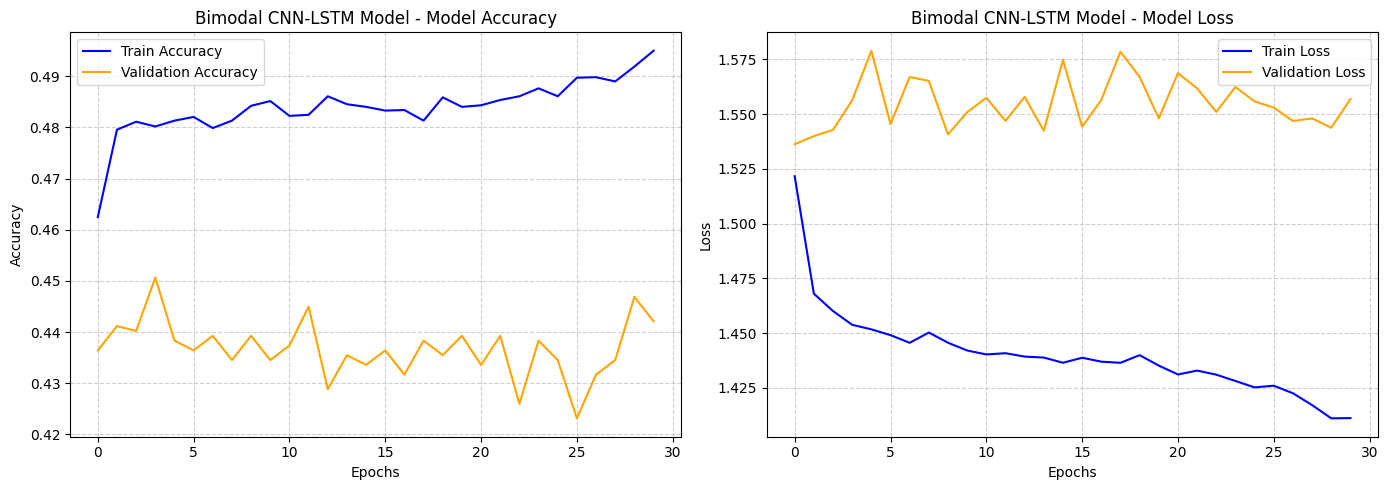


================ Evaluating Bimodal CNN-LSTM Model ================

--- Classification Report ---
              precision    recall  f1-score   support

       anger       0.28      0.10      0.14        52
     disgust       0.00      0.00      0.00         9
        fear       0.00      0.00      0.00         9
         joy       0.24      0.07      0.11        55
     neutral       0.51      0.92      0.65       156
     sadness       0.13      0.08      0.10        26
    surprise       0.17      0.03      0.05        32

    accuracy                           0.46       339
   macro avg       0.19      0.17      0.15       339
weighted avg       0.34      0.46      0.35       339



c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

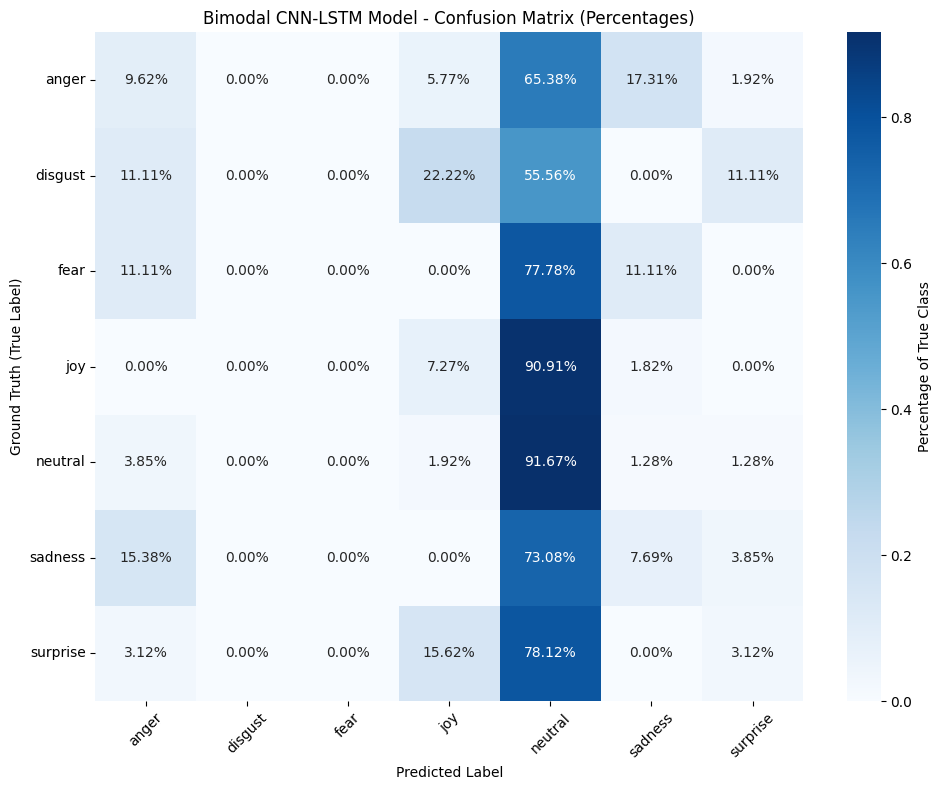

In [11]:
# ==========================================
# 4. EVALUATE
# ==========================================
plot_training_history(history_cnn_lstm, "Bimodal CNN-LSTM Model")
evaluate_model_performance(cnn_lstm_model, [X_test_mfcc, X_test_stats, X_test_txt], y_test, "Bimodal CNN-LSTM Model")

## BAN Model (Training & Testing)

In [12]:
# ==========================================
# 1. DEFINE INPUT BRANCHES
# ==========================================
# Branch 1: Acoustic MFCCs (Time-Series)
in_mfcc = layers.Input(shape=(Config.MAX_MFCC_LEN, Config.N_MFCC), name="in_mfcc")
x_mfcc = layers.Conv1D(64, 3, activation='relu', padding='same')(in_mfcc)
x_mfcc = layers.MaxPooling1D(2)(x_mfcc)
x_mfcc = layers.LSTM(64)(x_mfcc)

# Branch 2: Acoustic Statistical Features (Numeric)
in_stats = layers.Input(shape=(X_train_stats.shape[1],), name="in_stats")
x_stats = layers.Dense(32, activation='relu')(in_stats)
x_stats = layers.BatchNormalization()(x_stats)

# Combine Acoustic Features
x_audio_combined = layers.Concatenate()([x_mfcc, x_stats])
# Project combined audio to a fixed dimension (64) for attention matching
x_audio_proj = layers.Dense(64, activation='relu')(x_audio_combined)

# Branch 3: Textual Sentiment (One-Hot Encoded)
in_text = layers.Input(shape=(X_train_txt.shape[1],), name="in_text")
# Project the text input into the same dimensional space (64)
x_text = layers.Dense(64, activation='relu')(in_text) 

# ==========================================
# 2. CROSS-MODAL ATTENTION MECHANISM
# ==========================================
# The text features generate a sigmoid attention mask (values between 0 and 1)
attention_weights = layers.Dense(64, activation='sigmoid', name="text_guided_attention")(x_text)

# The attention mask is multiplied element-wise against the combined audio features.
# This forces the network to "pay attention" to specific audio signals based on the text sentiment.
attended_audio = layers.Multiply(name="attended_audio")([x_audio_proj, attention_weights])

# ==========================================
# 3. FUSION AND CLASSIFICATION
# ==========================================
# Concatenate the text-focused audio back with the original text context
merged = layers.Concatenate()([attended_audio, x_text])

# Fully Connected Layers
x = layers.Dense(128, activation='relu')(merged)
x = layers.Dropout(Config.DROPOUT)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Build the final BAN Model
ban_model = models.Model(inputs=[in_mfcc, in_stats, in_text], outputs=outputs)

In [13]:
# ==========================================
# 4. COMPILE AND TRAIN
# ==========================================
optimizer = optimizers.Adam(learning_rate=Config.LEARNING_RATE)
ban_model.compile(optimizer=optimizer, 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

print(f"Training BAN for exactly {Config.EPOCHS} epochs...")
history_ban = ban_model.fit(
    [X_train_mfcc, X_train_stats, X_train_txt], y_train,  
    validation_data=([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev),
    epochs=Config.EPOCHS,
    batch_size=Config.BATCH_SIZE,
    verbose=1
)

Training BAN for exactly 30 epochs...
Epoch 1/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4720 - loss: 1.4901 - val_accuracy: 0.4431 - val_loss: 1.5225
Epoch 2/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4776 - loss: 1.4558 - val_accuracy: 0.4440 - val_loss: 1.5357
Epoch 3/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4788 - loss: 1.4553 - val_accuracy: 0.4459 - val_loss: 1.5247
Epoch 4/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4801 - loss: 1.4513 - val_accuracy: 0.4345 - val_loss: 1.5428
Epoch 5/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4850 - loss: 1.4464 - val_accuracy: 0.4222 - val_loss: 1.5775
Epoch 6/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4841 - loss: 1.4407 - val_accuracy: 0.4383 - val_loss: 1.5345
Epoch 7/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4830 - loss: 1.4433 - val_accuracy: 0.4364 - val_loss: 1.5535
Epoch 8/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.

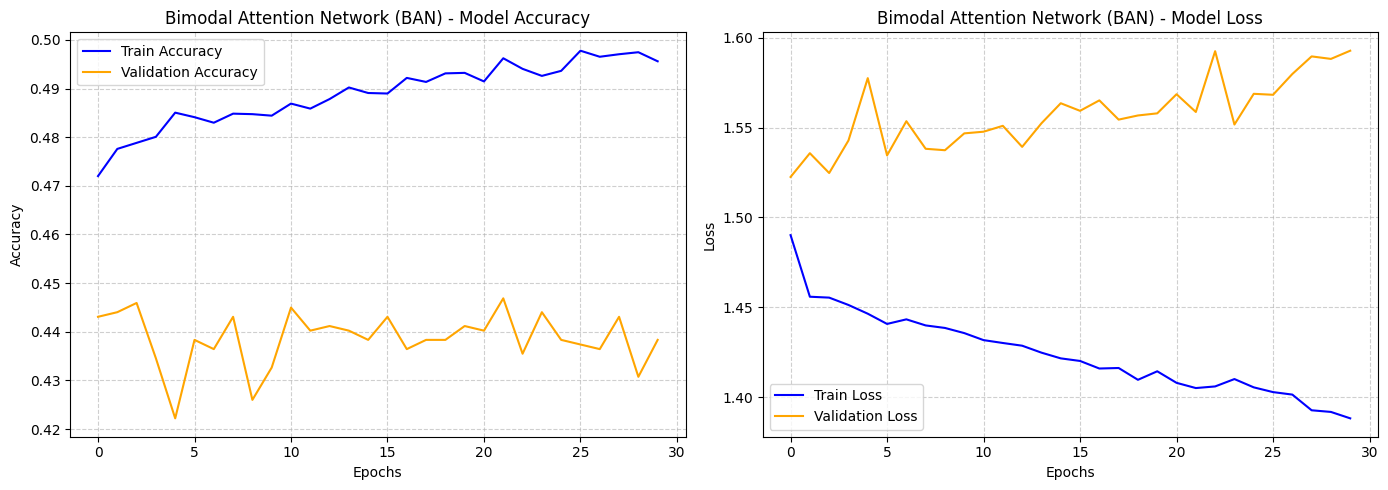


================ Evaluating Bimodal Attention Network (BAN) ================

--- Classification Report ---
              precision    recall  f1-score   support

       anger       0.39      0.17      0.24        52
     disgust       0.00      0.00      0.00         9
        fear       0.00      0.00      0.00         9
         joy       0.32      0.13      0.18        55
     neutral       0.50      0.90      0.65       156
     sadness       0.14      0.04      0.06        26
    surprise       0.17      0.03      0.05        32

    accuracy                           0.47       339
   macro avg       0.22      0.18      0.17       339
weighted avg       0.37      0.47      0.37       339



c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

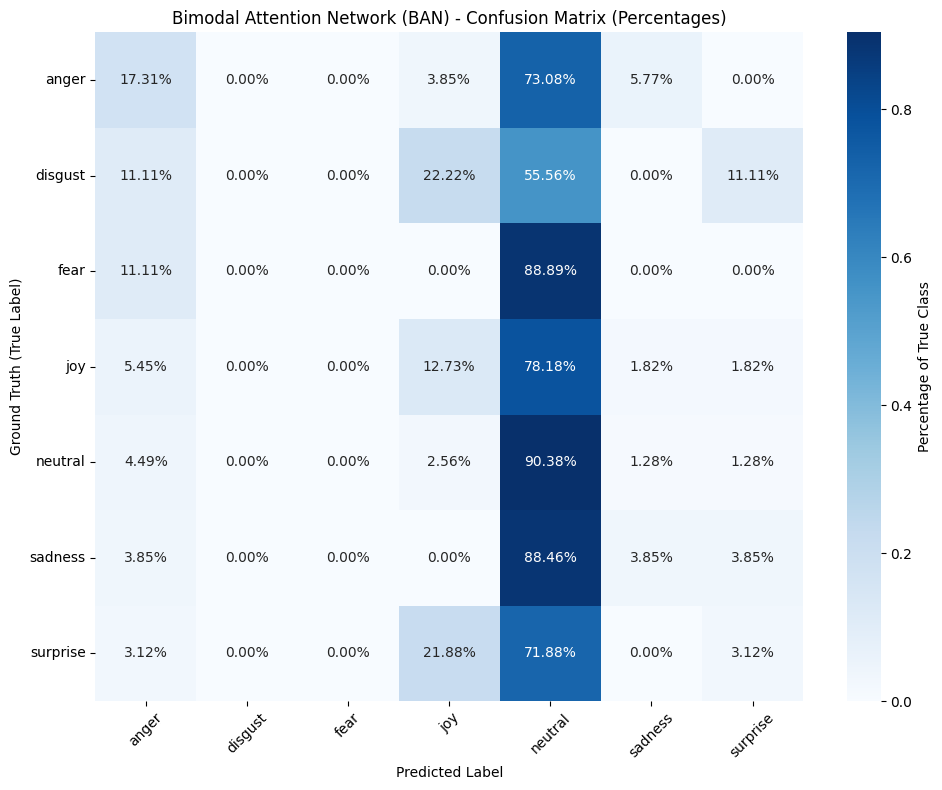

In [14]:
# ==========================================
# 5. EVALUATE
# ==========================================
plot_training_history(history_ban, "Bimodal Attention Network (BAN)")
evaluate_model_performance(ban_model, [X_test_mfcc, X_test_stats, X_test_txt], y_test, "Bimodal Attention Network (BAN)")